In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
import numpy as np

In [71]:
df = pd.read_csv(r'podaci\clickstream+data+for+online+shopping\e-shop clothing 2008.csv', encoding='cp1252', sep=';')
print(df.columns)

Index(['year', 'month', 'day', 'order', 'country', 'session ID',
       'page 1 (main category)', 'page 2 (clothing model)', 'colour',
       'location', 'model photography', 'price', 'price 2', 'page'],
      dtype='object')


In [72]:
df.head()

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,4,1,1,29,1,1,A13,1,5,1,28,2,1
1,2008,4,1,2,29,1,1,A16,1,6,1,33,2,1
2,2008,4,1,3,29,1,2,B4,10,2,1,52,1,1
3,2008,4,1,4,29,1,2,B17,6,6,2,38,2,1
4,2008,4,1,5,29,1,2,B8,4,3,2,52,1,1


In [73]:
print(df.isnull().sum())

year                       0
month                      0
day                        0
order                      0
country                    0
session ID                 0
page 1 (main category)     0
page 2 (clothing model)    0
colour                     0
location                   0
model photography          0
price                      0
price 2                    0
page                       0
dtype: int64


In [74]:
df_corr = df.drop('year',axis=1)
df_corr = df_corr.drop('session ID',axis=1)

In [75]:
df_corr

,month,day,order,country,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,4,1,1,29,1,A13,1,5,1,28,2,1
1,4,1,2,29,1,A16,1,6,1,33,2,1
2,4,1,3,29,2,B4,10,2,1,52,1,1
3,4,1,4,29,2,B17,6,6,2,38,2,1
4,4,1,5,29,2,B8,4,3,2,52,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
165469,8,13,1,29,2,B10,2,4,1,67,1,1
165470,8,13,1,9,1,A11,3,4,1,62,1,1
165471,8,13,1,34,1,A2,3,1,1,43,2,1
165472,8,13,2,34,3,C2,12,1,1,43,1,1


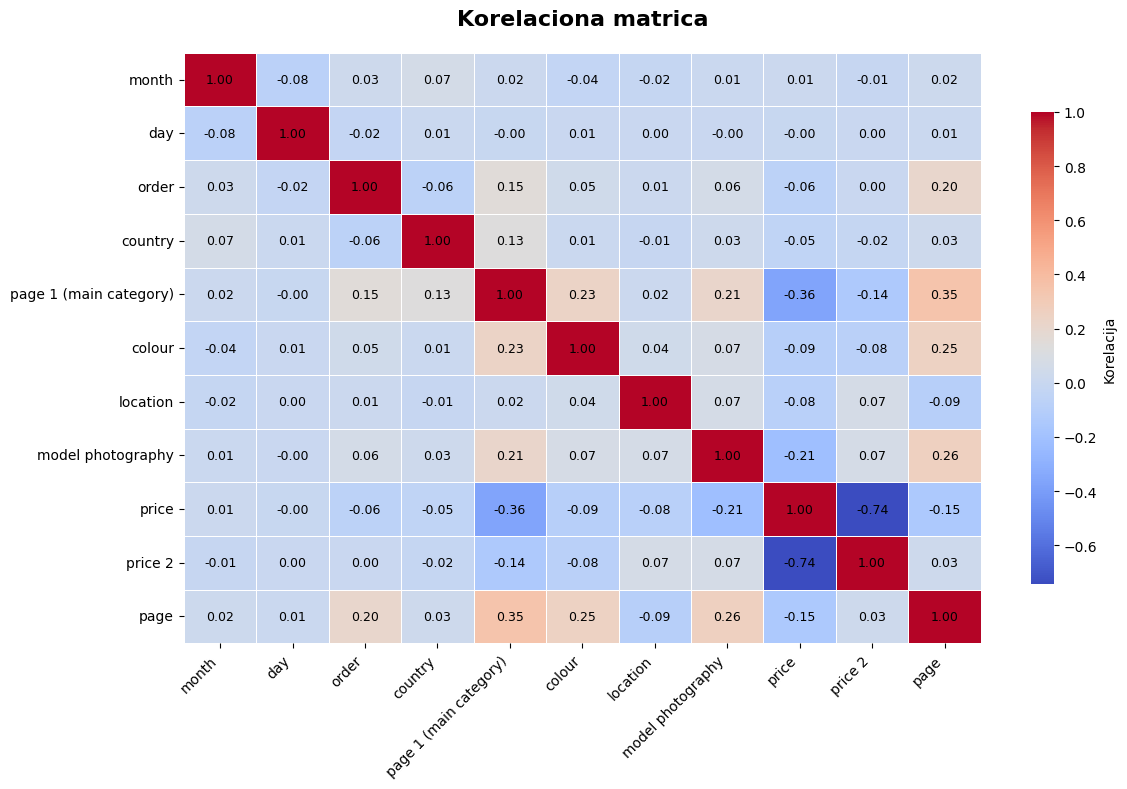

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

# Korelaciona matrica
korelacije = df_corr.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    korelacije,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",           # 2 decimale
    linewidths=0.5,      # tanke linije
    linecolor="white",
    cbar_kws={"shrink": .8, "label": "Korelacija"},
    annot_kws={"size": 9, "color": "black"}
)

plt.title("Korelaciona matrica", fontsize=16, pad=20, weight="bold")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


In [77]:
df['month'] = df['month'].replace({
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August'
})
df['month'].unique()

array(['April', 'May', 'June', 'July', 'August'], dtype=object)

Radi se na osnovu ip adrese

In [78]:
df['country'] = df['country'].replace({
    1: 'Australia',
    2: 'Austria',
    3: 'Belgium',
    4: 'British Virgin Islands',
    5: 'Cayman Islands',
    6: 'Christmas Island',
    7: 'Croatia',
    8: 'Cyprus',
    9: 'Czech Republic',
    10: 'Denmark',
    11: 'Estonia',
    12: 'unidentified',
    13: 'Faroe Islands',
    14: 'Finland',
    15: 'France',
    16: 'Germany',
    17: 'Greece',
    18: 'Hungary',
    19: 'Iceland',
    20: 'India',
    21: 'Ireland',
    22: 'Italy',
    23: 'Latvia',
    24: 'Lithuania',
    25: 'Luxembourg',
    26: 'Mexico',
    27: 'Netherlands',
    28: 'Norway',
    29: 'Poland',
    30: 'Portugal',
    31: 'Romania',
    32: 'Russia',
    33: 'San Marino',
    34: 'Slovakia',
    35: 'Slovenia',
    36: 'Spain',
    37: 'Sweden',
    38: 'Switzerland',
    39: 'Ukraine',
    40: 'United Arab Emirates',
    41: 'United Kingdom',
    42: 'USA',
    43: 'biz',
    44: 'com',
    45: 'int',
    46: 'net',
    47: 'org'
})
df['country'].unique()

array(['Poland', 'Ireland', 'Czech Republic', 'Germany', 'Switzerland',
       'Lithuania', 'United Kingdom', 'unidentified', 'Romania', 'com',
       'Slovakia', 'Norway', 'net', 'France', 'Denmark', 'Netherlands',
       'Croatia', 'Luxembourg', 'India', 'Greece', 'Italy', 'Iceland',
       'USA', 'Cyprus', 'Belgium', 'Sweden', 'Portugal', 'Finland', 'biz',
       'Latvia', 'org', 'Spain', 'Austria', 'San Marino', 'Russia', 'int',
       'Hungary', 'Estonia', 'United Arab Emirates', 'Christmas Island',
       'Ukraine', 'Australia', 'Slovenia', 'Faroe Islands',
       'British Virgin Islands', 'Mexico', 'Cayman Islands'], dtype=object)

In [79]:
df['page 1 (main category)'] = df['page 1 (main category)'].replace({
    1: 'trousers',
    2: 'skirts',
    3: 'blouses',
    4: 'sale'
})
df['page 1 (main category)'].unique()  

array(['trousers', 'skirts', 'blouses', 'sale'], dtype=object)

In [80]:
df['colour'] = df['colour'].replace({
    1: 'beige',
    2: 'black',
    3: 'blue',
    4: 'brown',
    5: 'burgundy',
    6: 'gray',
    7: 'green',
    8: 'navy blue',
    9: 'of many colors',
    10: 'olive',
    11: 'pink',
    12: 'red',
    13: 'violet',
    14: 'white'
})
df['colour'].unique()

array(['beige', 'olive', 'gray', 'brown', 'burgundy', 'of many colors',
       'red', 'pink', 'black', 'blue', 'violet', 'white', 'green',
       'navy blue'], dtype=object)

LOCATION -> pozicija slike na ekranu

In [81]:
df['location'] = df['location'].replace({
    1: 'top left',
    2: 'top in the middle',
    3: 'top right',
    4: 'bottom left',
    5: 'bottom in the middle',
    6: 'bottom right'
})
df['location'].unique()

array(['bottom in the middle', 'bottom right', 'top in the middle',
       'top right', 'top left', 'bottom left'], dtype=object)

In [82]:
df['model photography'] = df['model photography'].replace({
    1: 'en face',
    2: 'profile',
})
df['model photography'].unique()

array(['en face', 'profile'], dtype=object)

In [83]:
df['price 2'] = df['price 2'].replace({
    1: 'yes',
    2: 'no',
})
df['price 2'].unique()

array(['no', 'yes'], dtype=object)

Nakon mapiranja

In [84]:
df.head()

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,April,1,1,Poland,1,trousers,A13,beige,bottom in the middle,en face,28,no,1
1,2008,April,1,2,Poland,1,trousers,A16,beige,bottom right,en face,33,no,1
2,2008,April,1,3,Poland,1,skirts,B4,olive,top in the middle,en face,52,yes,1
3,2008,April,1,4,Poland,1,skirts,B17,gray,bottom right,profile,38,no,1
4,2008,April,1,5,Poland,1,skirts,B8,brown,top right,profile,52,yes,1


In [85]:
df.to_csv(r'podaci\clickstream+data+for+online+shopping\e-shop clothing 2008 show.csv', index=False)

In [86]:
df = pd.read_csv(r'podaci\clickstream+data+for+online+shopping\e-shop clothing 2008 show.csv', encoding='cp1252', sep=',')  
df

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,April,1,1,Poland,1,trousers,A13,beige,bottom in the middle,en face,28,no,1
1,2008,April,1,2,Poland,1,trousers,A16,beige,bottom right,en face,33,no,1
2,2008,April,1,3,Poland,1,skirts,B4,olive,top in the middle,en face,52,yes,1
3,2008,April,1,4,Poland,1,skirts,B17,gray,bottom right,profile,38,no,1
4,2008,April,1,5,Poland,1,skirts,B8,brown,top right,profile,52,yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165469,2008,August,13,1,Poland,24024,skirts,B10,black,bottom left,en face,67,yes,1
165470,2008,August,13,1,Czech Republic,24025,trousers,A11,blue,bottom left,en face,62,yes,1
165471,2008,August,13,1,Slovakia,24026,trousers,A2,blue,top left,en face,43,no,1
165472,2008,August,13,2,Slovakia,24026,blouses,C2,red,top left,en face,43,yes,1


In [87]:
print(df.describe())

           year            day          order     session ID          price  \
count  165474.0  165474.000000  165474.000000  165474.000000  165474.000000   
mean     2008.0      14.524554       9.817476   12058.417056      43.802507   
std         0.0       8.830374      13.478411    7008.418903      12.548131   
min      2008.0       1.000000       1.000000       1.000000      18.000000   
25%      2008.0       7.000000       2.000000    5931.000000      33.000000   
50%      2008.0      14.000000       6.000000   11967.500000      43.000000   
75%      2008.0      22.000000      12.000000   18219.000000      52.000000   
max      2008.0      31.000000     195.000000   24026.000000      82.000000   

                page  
count  165474.000000  
mean        1.710166  
std         0.982412  
min         1.000000  
25%         1.000000  
50%         1.000000  
75%         2.000000  
max         5.000000  


In [88]:
import os
os.makedirs("grafikoni", exist_ok=True)

In [89]:
for col in df.columns:
    plt.figure(figsize=(10, 5))
    if df[col].dtype == "object":
        df[col].value_counts().plot(kind="bar")
        plt.title(f"Distribucija vrijednosti - {col}")
        plt.ylabel("Broj pojavljivanja")
    elif df[col].nunique() < 30:  # kategorizovane numeričke kolone
        df[col].value_counts().sort_index().plot(kind="bar")
        plt.title(f"Distribucija vrijednosti - {col}")
        plt.ylabel("Broj pojavljivanja")
    else:  # numeričke kontinualne kolone
        sns.histplot(df[col], bins=30, kde=True)  # kde=True dodaje liniju raspodjele
        plt.title(f"Histogram - {col}")
        plt.xlabel("Vrijednosti")
        plt.ylabel("Frekvencija")
        plt.tight_layout()
    
    plt.tight_layout()
    # Snimanje grafa
    plt.savefig(f"grafikoni/{col}.png")
    plt.close()

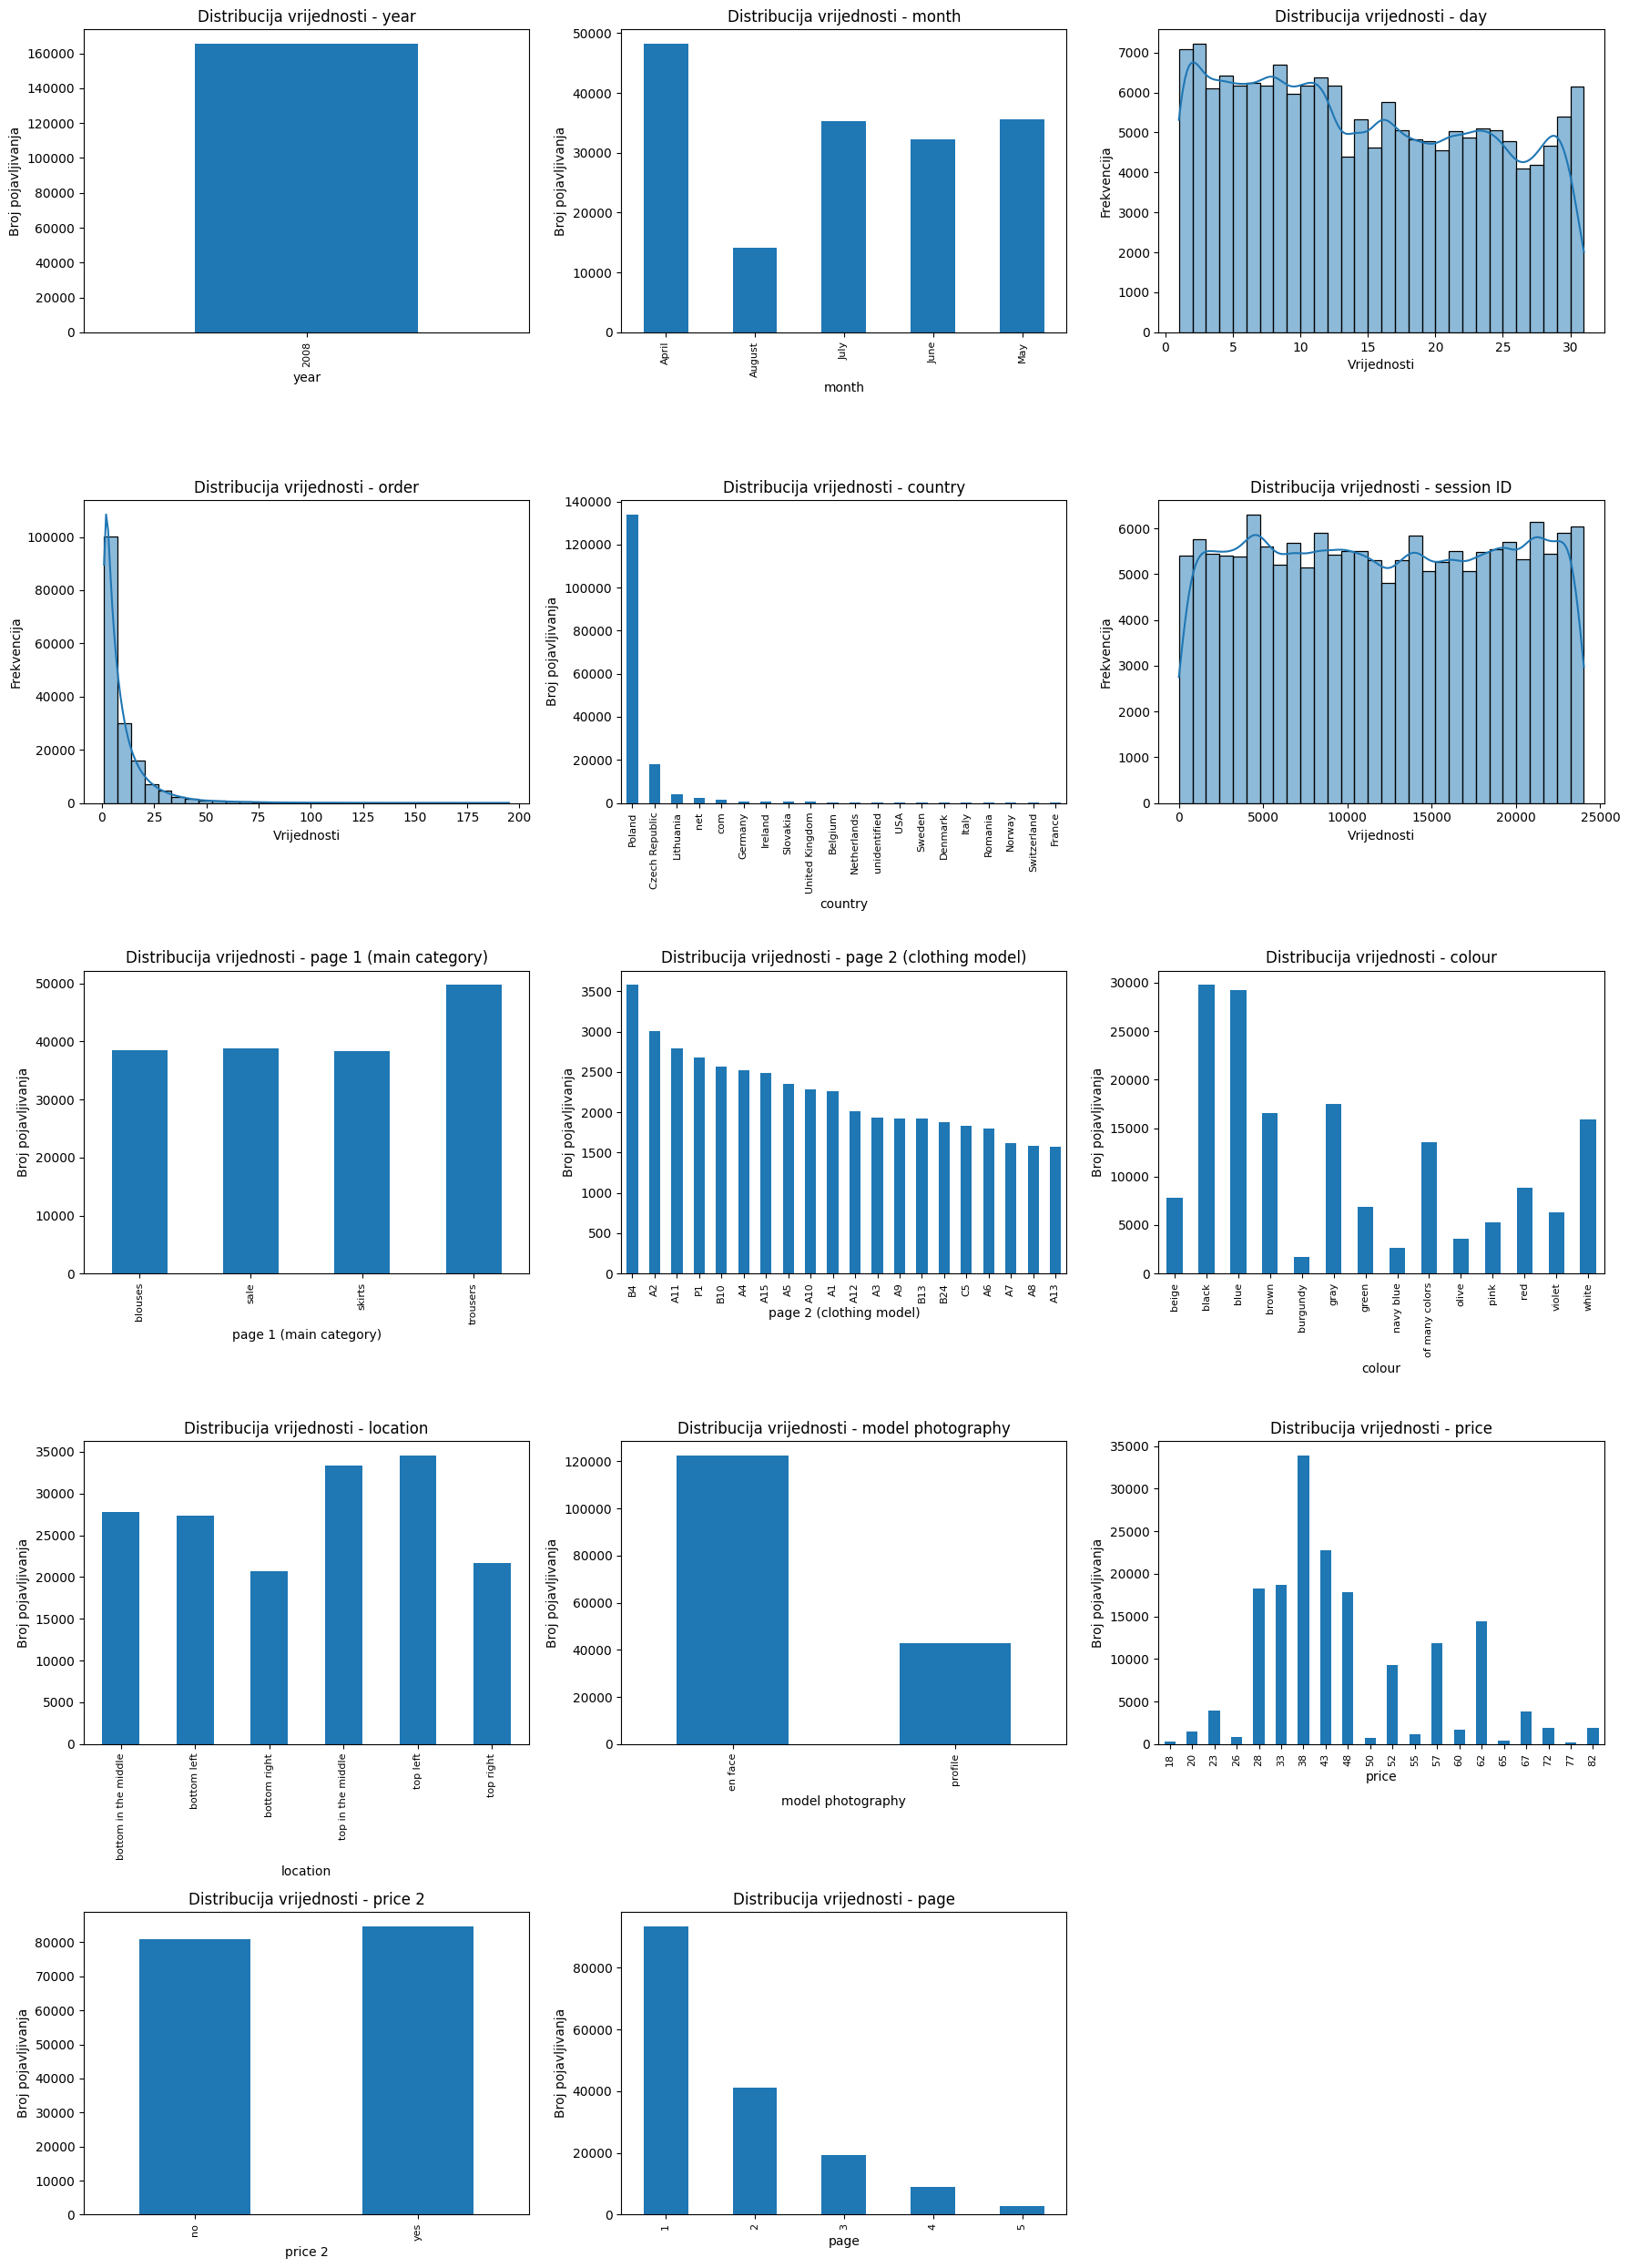

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_per_row = 3
n_cols = len(df.columns)
n_rows = (n_cols + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(18, 5 * n_rows))  # šira figura
axes = axes.flatten()

for i, col in enumerate(df.columns):
    ax = axes[i]
    
    if df[col].dtype == "object" or df[col].nunique() < 30:
        if col in ["country", "page 2 (clothing model)"]:
            df[col].value_counts().head(20).plot(kind="bar", ax=ax)
        else:
            df[col].value_counts().sort_index().plot(kind="bar", ax=ax)
        
        ax.set_ylabel("Broj pojavljivanja")
        ax.tick_params(axis="x", rotation=90, labelsize=8)  # uspravni tekst
    else:
        sns.histplot(df[col], bins=30, kde=True, ax=ax)
        ax.set_xlabel("Vrijednosti")
        ax.set_ylabel("Frekvencija")
    
    ax.set_title(f"Distribucija vrijednosti - {col}")

# obriši prazne axe-ove ako ih ima
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [91]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   year                     165474 non-null  int64 
 1   month                    165474 non-null  object
 2   day                      165474 non-null  int64 
 3   order                    165474 non-null  int64 
 4   country                  165474 non-null  object
 5   session ID               165474 non-null  int64 
 6   page 1 (main category)   165474 non-null  object
 7   page 2 (clothing model)  165474 non-null  object
 8   colour                   165474 non-null  object
 9   location                 165474 non-null  object
 10  model photography        165474 non-null  object
 11  price                    165474 non-null  int64 
 12  price 2                  165474 non-null  object
 13  page                     165474 non-null  int64 
dtypes: int64(6), object(

In [92]:
print(f"Ukupno modela odjeće: {df['page 2 (clothing model)'].nunique()}")

Ukupno modela odjeće: 217


In [93]:
print(df['page 1 (main category)'].value_counts())

page 1 (main category)
trousers    49742
sale        38747
blouses     38577
skirts      38408
Name: count, dtype: int64


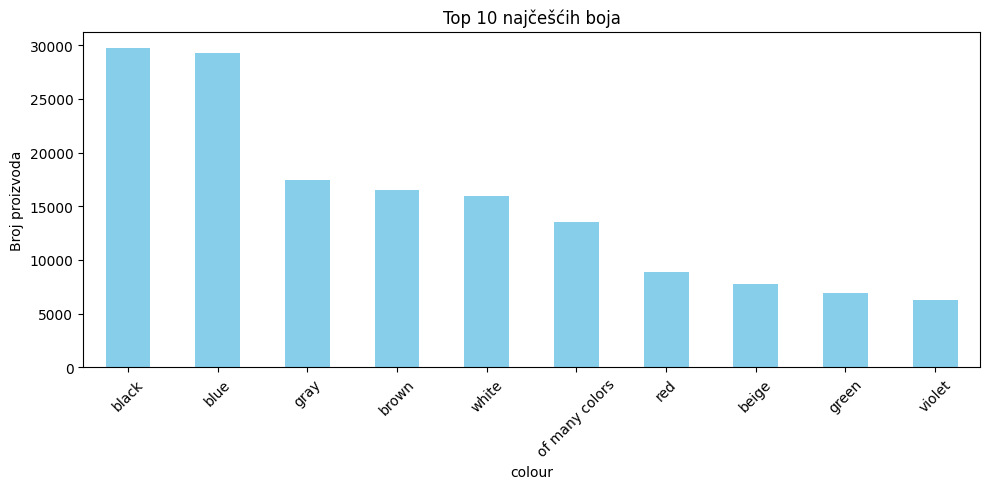

In [94]:
plt.figure(figsize=(10,5))
df['colour'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 najčešćih boja")
plt.ylabel("Broj proizvoda")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

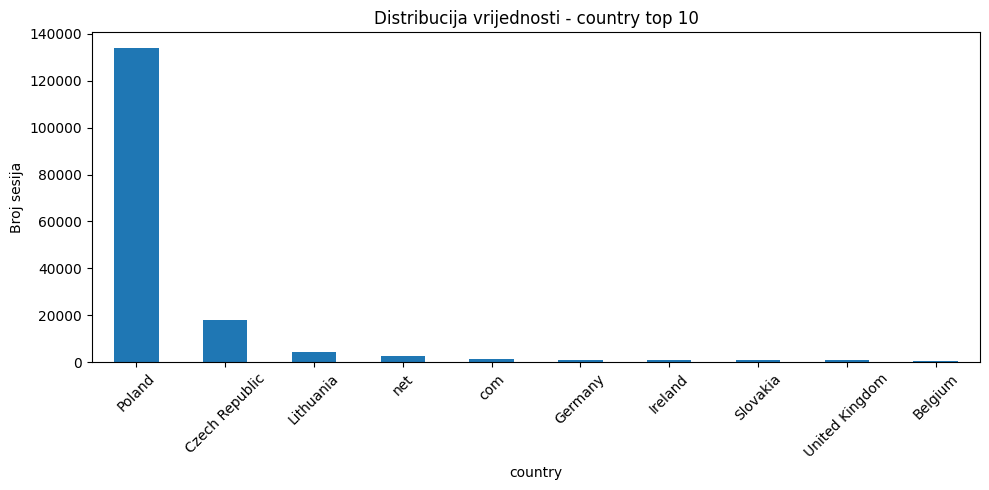

In [95]:
#  Broj sesija po zemlji
plt.figure(figsize=(10,5))
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Distribucija vrijednosti - country top 10")
plt.ylabel("Broj sesija")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

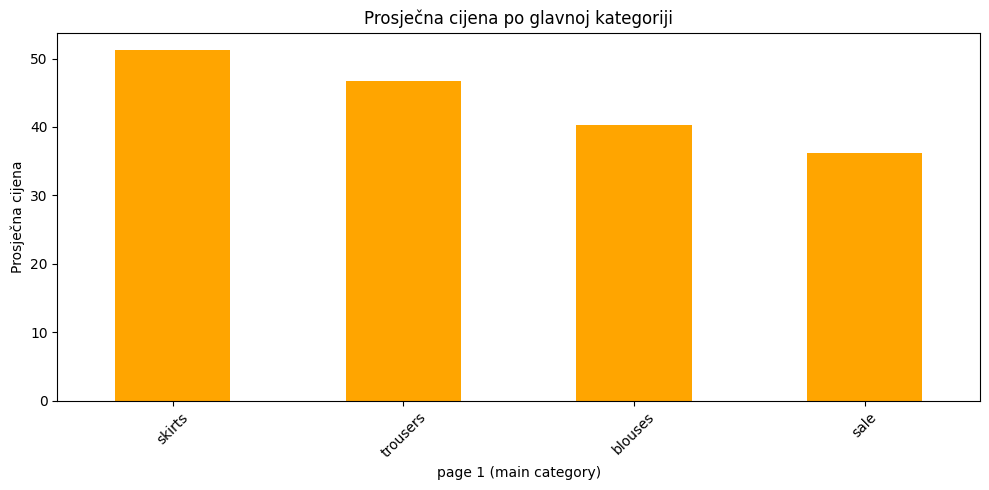

In [96]:
avg_price_category = df.groupby('page 1 (main category)')['price'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
avg_price_category.plot(kind='bar', color='orange')
plt.title("Prosječna cijena po glavnoj kategoriji")
plt.ylabel("Prosječna cijena")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [97]:
print("Prosječna cijena svih proizvoda je:", round(df['price'].mean(), 2))

Prosječna cijena svih proizvoda je: 43.8


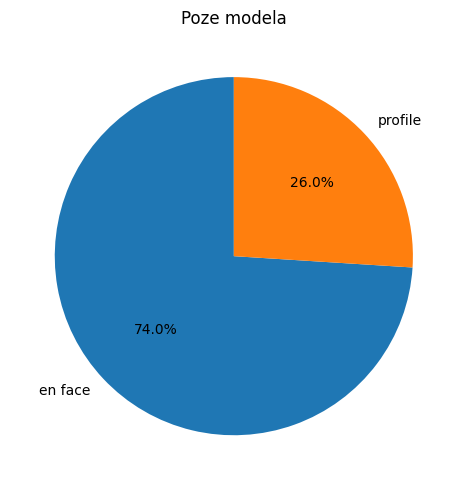

In [98]:
plt.figure(figsize=(8,5))
df['model photography'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Poze modela")
plt.ylabel('')
plt.tight_layout()
plt.show()

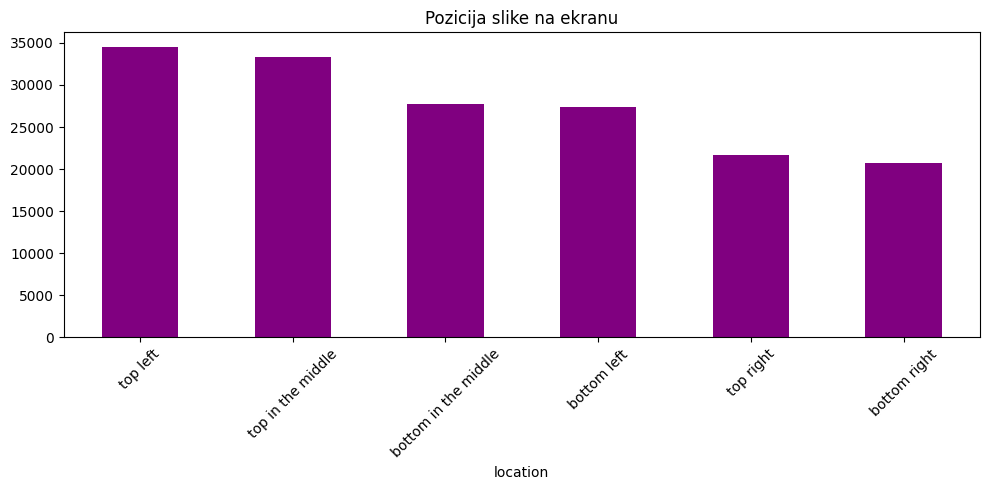

In [99]:
plt.figure(figsize=(10,5))
df['location'].value_counts().head(10).plot(kind='bar', color='purple')
plt.title('Pozicija slike na ekranu')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()